In [ ]:
pip install h5py

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 70.8 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [10]:
import h5py
import uproot
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt

In [17]:
import glob
import uproot
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt

file_patterns = [
    "/share/data1/yzhu/dijet/user.yuanda.mc20_13TeV.364700.e7142_s3681_r13144_p6859.parent_ANALYSIS.root/*.root",
    "/share/data1/yzhu/dijet/user.yuanda.mc20_13TeV.364701.e7142_s3681_r13144_p6859.parent_ANALYSIS.root/*.root",
]


In [18]:

files = []
for pattern in file_patterns:
    matches = glob.glob(pattern)
    print(f"Pattern found {len(matches)} files: {pattern}")
    files.extend(matches)

if not files:
    print("WARNING: No files found. Please check the paths.")


Pattern found 5 files: /share/data1/yzhu/dijet/user.yuanda.mc20_13TeV.364700.e7142_s3681_r13144_p6859.parent_ANALYSIS.root/*.root
Pattern found 6 files: /share/data1/yzhu/dijet/user.yuanda.mc20_13TeV.364701.e7142_s3681_r13144_p6859.parent_ANALYSIS.root/*.root


In [19]:
print(f"files: {files}")

files: ['/share/data1/yzhu/dijet/user.yuanda.mc20_13TeV.364700.e7142_s3681_r13144_p6859.parent_ANALYSIS.root/user.yuanda.47860631._000001.ANALYSIS.root', '/share/data1/yzhu/dijet/user.yuanda.mc20_13TeV.364700.e7142_s3681_r13144_p6859.parent_ANALYSIS.root/user.yuanda.47860631._000002.ANALYSIS.root', '/share/data1/yzhu/dijet/user.yuanda.mc20_13TeV.364700.e7142_s3681_r13144_p6859.parent_ANALYSIS.root/user.yuanda.47860631._000003.ANALYSIS.root', '/share/data1/yzhu/dijet/user.yuanda.mc20_13TeV.364700.e7142_s3681_r13144_p6859.parent_ANALYSIS.root/user.yuanda.47860631._000004.ANALYSIS.root', '/share/data1/yzhu/dijet/user.yuanda.mc20_13TeV.364700.e7142_s3681_r13144_p6859.parent_ANALYSIS.root/user.yuanda.47860631._000005.ANALYSIS.root', '/share/data1/yzhu/dijet/user.yuanda.mc20_13TeV.364701.e7142_s3681_r13144_p6859.parent_ANALYSIS.root/user.yuanda.47860632._000001.ANALYSIS.root', '/share/data1/yzhu/dijet/user.yuanda.mc20_13TeV.364701.e7142_s3681_r13144_p6859.parent_ANALYSIS.root/user.yuanda.478

In [25]:
# Inspect SRJ_pt structure in detail for the first file
import uproot
import awkward as ak
import numpy as np

# Use the first file for inspection
test_file = files[0]
print(f"Inspecting file: {test_file}")

with uproot.open(test_file) as f:
    # Find tree
    tree_name = None
    for key in f.keys():
        if "AnalysisTree" in key:
            tree_name = key
            break
    
    if tree_name:
        tree = f[tree_name]
        print(f"Tree found: {tree_name}")
        
        # Check branch type
        if "SRJ_pt" in tree.keys():
            branch = tree["SRJ_pt"]
            print(f"Branch 'SRJ_pt' type: {branch.interpretation}")
            
            # Read array
            srj_pt = branch.array(library="ak")
            print(f"Array type: {srj_pt.type}")
            print(f"Number of events: {len(srj_pt)}")
            
            # Check how many events have jets
            num_jets = ak.num(srj_pt)
            events_with_jets = ak.sum(num_jets > 0)
            total_jets = ak.sum(num_jets)
            
            print(f"Events with >0 jets: {events_with_jets} ({events_with_jets/len(srj_pt)*100:.2f}%)")
            print(f"Total jets: {total_jets}")
            
            # Print first 20 events
            print("\nFirst 20 events content:")
            print(srj_pt[:20])
            
            # If mostly empty, find first non-empty event
            if events_with_jets > 0:
                non_empty_idx = np.where(ak.to_numpy(num_jets) > 0)[0]
                print(f"\nFirst 5 non-empty events (indices {non_empty_idx[:5]}):")
                print(srj_pt[non_empty_idx[:5]])
                
                # Check values
                flat_pt = ak.flatten(srj_pt)
                print(f"\nValue stats (Min/Max/Mean): {np.min(flat_pt):.2f} / {np.max(flat_pt):.2f} / {np.mean(flat_pt):.2f}")
            else:
                print("\nWARNING: No jets found in this file!")
                
        else:
            print("Branch 'SRJ_pt' not found!")
    else:
        print("AnalysisTree not found!")

Inspecting file: /share/data1/yzhu/dijet/user.yuanda.mc20_13TeV.364700.e7142_s3681_r13144_p6859.parent_ANALYSIS.root/user.yuanda.47860631._000001.ANALYSIS.root
Tree found: AnalysisTree;1
Branch 'SRJ_pt' type: AsJagged(AsDtype('>f8'), header_bytes=10)
Array type: 1177121 * var * float64
Number of events: 1177121
Events with >0 jets: 7782 (0.66%)
Total jets: 9580

First 20 events content:
[[], [], [], [], [], [], [], [], [], ..., [], [], [], [], [], [], [], [], []]

First 5 non-empty events (indices [ 31  71  97 113 199]):
[[109], [80.1, 66.4], [95.3, 87.2], [65.9], [70.8, 69.8]]

Value stats (Min/Max/Mean): 60.00 / 486.27 / 77.68
Array type: 1177121 * var * float64
Number of events: 1177121
Events with >0 jets: 7782 (0.66%)
Total jets: 9580

First 20 events content:
[[], [], [], [], [], [], [], [], [], ..., [], [], [], [], [], [], [], [], []]

First 5 non-empty events (indices [ 31  71  97 113 199]):
[[109], [80.1, 66.4], [95.3, 87.2], [65.9], [70.8, 69.8]]

Value stats (Min/Max/Mean): 

Processing 11 files...
File 0: Selected 9462 jets
File 0: Selected 9462 jets
File 1: Selected 48334 jets
File 1: Selected 48334 jets
File 2: Selected 22638 jets
File 2: Selected 22638 jets

Total selected jets: 370212
Data range: 60.00 - 159.99 GeV

Total selected jets: 370212
Data range: 60.00 - 159.99 GeV


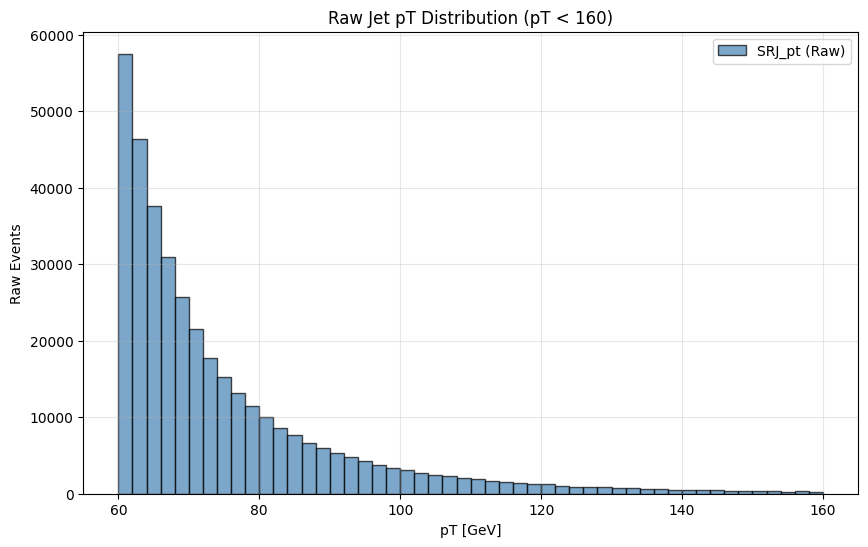

In [32]:
# Process all files and plot raw distribution (no weights)
import matplotlib.pyplot as plt
import numpy as np
import awkward as ak
import uproot

all_pt = []

print(f"Processing {len(files)} files...")

for i, file_path in enumerate(files):
    try:
        with uproot.open(file_path) as f:
            # 1. Find AnalysisTree
            tree_name = None
            for key in f.keys():
                if "AnalysisTree" in key:
                    tree_name = key
                    break
            
            if not tree_name:
                continue
                
            tree = f[tree_name]
            
            # 2. Read Data
            if "SRJ_pt" not in tree.keys():
                print(f"Skipping {file_path}: Missing SRJ_pt")
                continue
                
            pt = tree["SRJ_pt"].array(library="ak")
            
            # 3. Apply Cuts (Jagged)
            # Cut: pt < 160
            mask = (pt < 160)
            
            sel_pt = pt[mask]
            
            # Flatten for histogramming
            flat_pt = ak.flatten(sel_pt)
            
            if len(flat_pt) > 0:
                all_pt.append(ak.to_numpy(flat_pt))
                if i < 3: 
                    print(f"File {i}: Selected {len(flat_pt)} jets")
            
    except Exception as e:
        print(f"Error reading {file_path}: {e}")

# Concatenate all
if all_pt:
    final_pt = np.concatenate(all_pt)
    
    print(f"\nTotal selected jets: {len(final_pt)}")
    print(f"Data range: {final_pt.min():.2f} - {final_pt.max():.2f} GeV")
    
    # Plot
    plt.figure(figsize=(10, 6))
    plt.hist(final_pt, bins=50, alpha=0.7, label='SRJ_pt (Raw)', color='steelblue', edgecolor='black')
    
    plt.xlabel('pT [GeV]')
    plt.ylabel('Raw Events')
    plt.title('Raw Jet pT Distribution (pT < 160)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("No jets passed the selection cuts across all files.")

Processing 11 files with weighting (No Cuts)...
File 0 Metadata: xs=1.0, eff=1.0, kf=0.0, sow=1.0
File 0 Norm Factor: 0.0
File 0: Selected 9580 jets
File 0 Weights: Min=0.00e+00, Max=0.00e+00, Mean=0.00e+00
File 0: Selected 9580 jets
File 0 Weights: Min=0.00e+00, Max=0.00e+00, Mean=0.00e+00

Total selected jets: 374596
Data range: 60.00 - 656.31 GeV
Total Weight Sum: 0.00e+00

Total selected jets: 374596
Data range: 60.00 - 656.31 GeV
Total Weight Sum: 0.00e+00


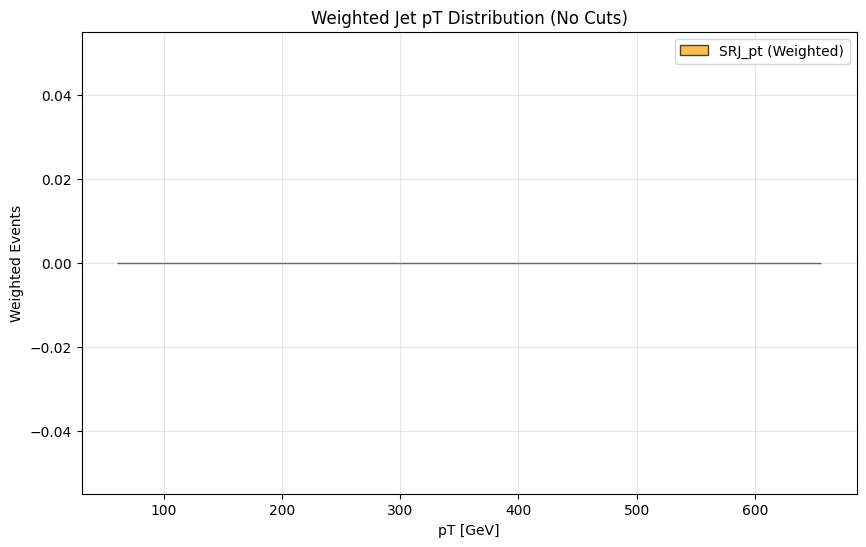

In [34]:
# Process all files and plot WITH WEIGHTS (No Cuts)
import matplotlib.pyplot as plt
import numpy as np
import awkward as ak
import uproot

all_pt = []
all_weights = []

print(f"Processing {len(files)} files with weighting (No Cuts)...")

for i, file_path in enumerate(files):
    try:
        with uproot.open(file_path) as f:
            # 1. Find AnalysisTree
            tree_name = None
            for key in f.keys():
                if "AnalysisTree" in key:
                    tree_name = key
                    break
            
            if not tree_name:
                continue
                
            tree = f[tree_name]
            
            # 2. Get Metadata for Normalization
            meta_name = None
            for key in f.keys():
                if "MetadataTree" in key:
                    meta_name = key
                    break
            
            norm_factor = 1.0
            if meta_name:
                meta_tree = f[meta_name]
                def get_val(t, name):
                    for k in t.keys():
                        if name.lower() in k.lower():
                            return t[k].array()[0]
                    return 1.0

                xs = get_val(meta_tree, "crossSection")
                eff = get_val(meta_tree, "filterEfficiency")
                kf = get_val(meta_tree, "kFactor")
                sow = get_val(meta_tree, "sumOfWeights")
                
                if sow != 0:
                    norm_factor = (xs * eff * kf) / sow
                    
                if i == 0:
                    print(f"File 0 Metadata: xs={xs}, eff={eff}, kf={kf}, sow={sow}")
                    print(f"File 0 Norm Factor: {norm_factor}")
            
            # 3. Read Data
            keys = tree.keys()
            if not all(k in keys for k in ["SRJ_pt", "mcEventWeight"]):
                print(f"Skipping {file_path}: Missing required branches")
                continue
                
            pt = tree["SRJ_pt"].array(library="ak")
            w = tree["mcEventWeight"].array(library="ak")
            
            # Broadcast weight to match jagged structure of pt
            w_broadcasted = ak.broadcast_arrays(w, pt)[0]
            
            # 4. Apply Cuts (Jagged)
            # No cuts applied
            sel_pt = pt
            sel_w = w_broadcasted * norm_factor
            
            # Flatten for histogramming
            flat_pt = ak.flatten(sel_pt)
            flat_w = ak.flatten(sel_w)
            
            if len(flat_pt) > 0:
                all_pt.append(ak.to_numpy(flat_pt))
                all_weights.append(ak.to_numpy(flat_w))
                if i == 0: 
                    print(f"File 0: Selected {len(flat_pt)} jets")
                    print(f"File 0 Weights: Min={np.min(flat_w):.2e}, Max={np.max(flat_w):.2e}, Mean={np.mean(flat_w):.2e}")
            
    except Exception as e:
        print(f"Error reading {file_path}: {e}")

# Concatenate all
if all_pt:
    final_pt = np.concatenate(all_pt)
    final_weights = np.concatenate(all_weights)
    
    print(f"\nTotal selected jets: {len(final_pt)}")
    print(f"Data range: {final_pt.min():.2f} - {final_pt.max():.2f} GeV")
    print(f"Total Weight Sum: {np.sum(final_weights):.2e}")
    
    # Plot
    plt.figure(figsize=(10, 6))
    plt.hist(final_pt, weights=final_weights, bins=50, alpha=0.7, label='SRJ_pt (Weighted)', color='orange', edgecolor='black')
    
    plt.xlabel('pT [GeV]')
    plt.ylabel('Weighted Events')
    plt.title('Weighted Jet pT Distribution (No Cuts)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("No jets passed the selection cuts across all files.")

Debugging Weights and Normalization...

Metadata for user.yuanda.47860631._000001.ANALYSIS.root:
  Cross Section (xs): 1.0
  Filter Efficiency (eff): 1.0
  k-Factor (kf): 0.0
  Sum of Weights (sow): 1.0
  Calculated Norm Factor: 0.000000e+00

Raw mcEventWeight Stats:
  Count: 1177121
  Min: 1.000000e+00
  Max: 1.000000e+00
  Mean: 1.000000e+00
  NaNs: 0

Final Weight (Raw * Norm) Stats:
  Min: 0.000000e+00
  Max: 0.000000e+00
  Mean: 0.000000e+00
  Min: 1.000000e+00
  Max: 1.000000e+00
  Mean: 1.000000e+00
  NaNs: 0

Final Weight (Raw * Norm) Stats:
  Min: 0.000000e+00
  Max: 0.000000e+00
  Mean: 0.000000e+00


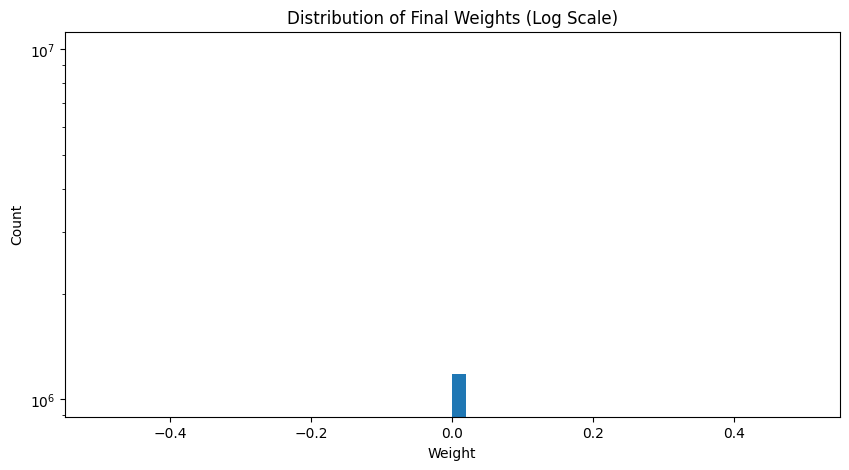


99th Percentile of weights: 0.000000e+00


In [35]:
# Debugging Weights and Normalization
import matplotlib.pyplot as plt
import numpy as np
import awkward as ak
import uproot

print("Debugging Weights and Normalization...")

# Check first file only for detailed inspection
test_file = files[0]
with uproot.open(test_file) as f:
    # 1. Metadata
    meta_name = None
    for key in f.keys():
        if "MetadataTree" in key:
            meta_name = key
            break
    
    norm_factor = 1.0
    if meta_name:
        meta_tree = f[meta_name]
        def get_val(t, name):
            for k in t.keys():
                if name.lower() in k.lower():
                    return t[k].array()[0]
            return 1.0

        xs = get_val(meta_tree, "crossSection")
        eff = get_val(meta_tree, "filterEfficiency")
        kf = get_val(meta_tree, "kFactor")
        sow = get_val(meta_tree, "sumOfWeights")
        
        print(f"\nMetadata for {test_file.split('/')[-1]}:")
        print(f"  Cross Section (xs): {xs}")
        print(f"  Filter Efficiency (eff): {eff}")
        print(f"  k-Factor (kf): {kf}")
        print(f"  Sum of Weights (sow): {sow}")
        
        if sow != 0:
            norm_factor = (xs * eff * kf) / sow
            print(f"  Calculated Norm Factor: {norm_factor:.6e}")
        else:
            print("  WARNING: Sum of Weights is 0!")

    # 2. Event Weights
    tree_name = None
    for key in f.keys():
        if "AnalysisTree" in key:
            tree_name = key
            break
            
    if tree_name:
        tree = f[tree_name]
        if "mcEventWeight" in tree.keys():
            w = tree["mcEventWeight"].array(library="ak")
            # mcEventWeight is usually 1D (per event)
            # Flatten just in case it's jagged, though it shouldn't be for event weights
            flat_w = ak.flatten(w, axis=None) 
            
            print(f"\nRaw mcEventWeight Stats:")
            print(f"  Count: {len(flat_w)}")
            print(f"  Min: {np.min(flat_w):.6e}")
            print(f"  Max: {np.max(flat_w):.6e}")
            print(f"  Mean: {np.mean(flat_w):.6e}")
            print(f"  NaNs: {np.sum(np.isnan(flat_w))}")
            
            final_w = flat_w * norm_factor
            print(f"\nFinal Weight (Raw * Norm) Stats:")
            print(f"  Min: {np.min(final_w):.6e}")
            print(f"  Max: {np.max(final_w):.6e}")
            print(f"  Mean: {np.mean(final_w):.6e}")
            
            # Plot weight distribution
            plt.figure(figsize=(10, 5))
            plt.hist(final_w, bins=50, log=True)
            plt.title("Distribution of Final Weights (Log Scale)")
            plt.xlabel("Weight")
            plt.ylabel("Count")
            plt.show()
            
            # Check for outliers
            q99 = np.quantile(final_w, 0.99)
            print(f"\n99th Percentile of weights: {q99:.6e}")
            if np.max(final_w) > q99 * 100:
                print("  WARNING: Extreme outliers detected in weights!")
        else:
            print("mcEventWeight branch not found!")

Processing 11 files with pT and Eta cuts...
File 0: Selected 870 jets passing both cuts
File 0: Selected 870 jets passing both cuts

Total selected jets: 37610
Data range: 60.00 - 159.93 GeV
Total Weight Sum: 0.00e+00

Total selected jets: 37610
Data range: 60.00 - 159.93 GeV
Total Weight Sum: 0.00e+00


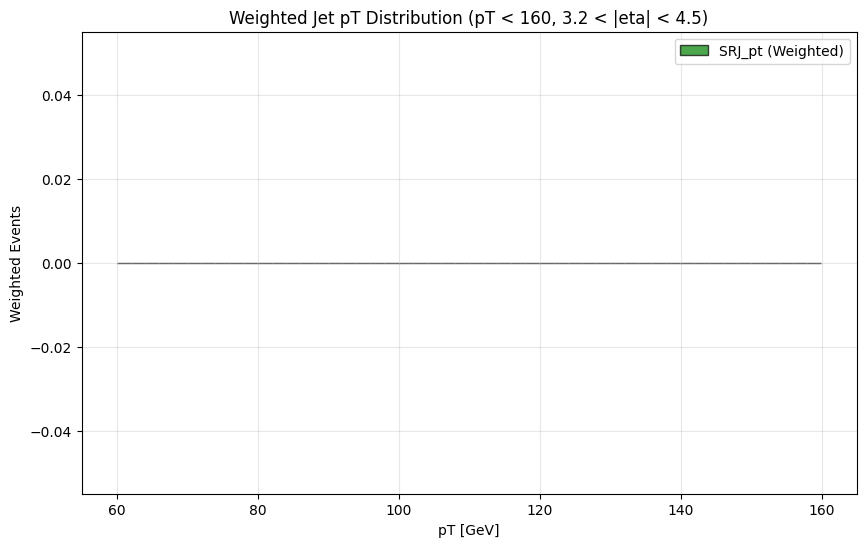

In [ ]:
# Process all files and plot RAW (No Weights) with BOTH CUTS
import matplotlib.pyplot as plt
import numpy as np
import awkward as ak
import uproot

all_pt = []

print(f"Processing {len(files)} files with pT and Eta cuts (Raw)...")

for i, file_path in enumerate(files):
    try:
        with uproot.open(file_path) as f:
            # 1. Find AnalysisTree
            tree_name = None
            for key in f.keys():
                if "AnalysisTree" in key:
                    tree_name = key
                    break
            
            if not tree_name:
                continue
                
            tree = f[tree_name]
            
            # 2. Read Data
            keys = tree.keys()
            if not all(k in keys for k in ["SRJ_pt", "SRJ_eta"]):
                print(f"Skipping {file_path}: Missing required branches")
                continue
                
            pt = tree["SRJ_pt"].array(library="ak")
            eta = tree["SRJ_eta"].array(library="ak")
            
            # 3. Apply Cuts (Jagged)
            # Cuts: pt < 160 AND 3.2 < |eta| < 4.5
            mask = (pt < 160) & (np.abs(eta) > 3.2) & (np.abs(eta) < 4.5)
            
            sel_pt = pt[mask]
            
            # Flatten for histogramming
            flat_pt = ak.flatten(sel_pt)
            
            if len(flat_pt) > 0:
                all_pt.append(ak.to_numpy(flat_pt))
                if i == 0: 
                    print(f"File 0: Selected {len(flat_pt)} jets passing both cuts")
            
    except Exception as e:
        print(f"Error reading {file_path}: {e}")

# Concatenate all
if all_pt:
    final_pt = np.concatenate(all_pt)
    
    print(f"\nTotal selected jets: {len(final_pt)}")
    print(f"Data range: {final_pt.min():.2f} - {final_pt.max():.2f} GeV")
    
    # Plot
    plt.figure(figsize=(10, 6))
    plt.hist(final_pt, bins=50, alpha=0.7, label='SRJ_pt (Raw)', color='purple', edgecolor='black')
    
    plt.xlabel('pT [GeV]')
    plt.ylabel('Raw Events')
    plt.title('Raw Jet pT Distribution (pT < 160, 3.2 < |eta| < 4.5)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("No jets passed the selection cuts (pT < 160, 3.2 < |eta| < 4.5) across all files.")